# 08 — Protected Areas (WDPA)

Prepare the complete Swiss protected areas dataset from the
World Database on Protected Areas (WDPA / UNEP-WCMC).

**Source**: https://www.protectedplanet.net/country/CHE  
**Format**: Shapefile (bulk download)  
**Storage**: `s3://km-cas-datalake/raw/wdpa/`

**Pipeline**:
1. Load the WDPA shapefile from S3
2. Filter to polygon records (drop points), terrestrial only
3. Select and rename relevant columns
4. Ensure CRS is EPSG:4326 (matching our raster stack)
5. Summarise by IUCN category and designation type
6. Save cleaned GeoJSON locally for use in gap analysis (notebook 31)

**Note**: The previous `protected_areas_ch.geojson` contained only 1,000 features
(a subset — likely a pagination artefact from the API). The full WDPA download
for Switzerland contains ~10,700+ polygon records covering ~4,100 km² (~10% of land area).

### IUCN Protected Area Management Categories

| Category | Name | Description |
|----------|------|-------------|
| **Ia** | Strict Nature Reserve | Strictly protected for biodiversity and geological/geomorphological features; human visitation, use and impacts are strictly controlled |
| **Ib** | Wilderness Area | Usually large unmodified areas, retaining their natural character, without permanent human habitation |
| **II** | National Park | Large natural or near-natural areas protecting large-scale ecological processes, with opportunities for compatible recreation |
| **III** | Natural Monument | Set aside to protect a specific natural monument (landform, sea mount, cave, geological feature) |
| **IV** | Habitat/Species Management Area | Protect particular species or habitats; management reflects this priority, often with active intervention |
| **V** | Protected Landscape/Seascape | Where interaction of people and nature over time has produced a distinct character with significant ecological, biological, cultural and scenic value |
| **VI** | Protected Area with Sustainable Use | Conserve ecosystems and habitats together with associated cultural values and traditional natural resource management systems |
| **Not Reported** | — | IUCN category not assigned or not communicated to WDPA |
| **Not Applicable** | — | Used for OECMs or sites where IUCN categories do not apply |

Categories Ia–III are the most restrictive (strict protection).  
Categories IV–VI allow increasing levels of human use and management intervention.  

Source: [IUCN Guidelines for Applying Protected Area Management Categories](https://www.iucn.org/content/guidelines-applying-protected-area-management-categories)

### Setup

In [8]:
import config
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import tempfile
import os

# S3 path where the WDPA shapefile zip is stored
WDPA_S3_PATH = f'{config.S3_RAW}/wdpa/'

# Output path (local, used by notebook 31)
OUTPUT_GEOJSON = 'protected_areas_ch.geojson'

print(f'WDPA source: {WDPA_S3_PATH}')
print(f'Output: {OUTPUT_GEOJSON}')

WDPA source: s3://km-cas-datalake/raw/wdpa/
Output: protected_areas_ch.geojson


### 1. Load WDPA shapefiles from S3

The WDPA bulk download is split into 3 zip files (due to size limits).
Each zip contains both polygon and point shapefiles. We download all 3,
extract the polygon shapefiles, and merge them into one GeoDataFrame.

Data location: `s3://km-cas-datalake/raw/wdpa/WDPA_WDOECM_May2026_Public_CHE_shp/`

In [9]:
import boto3

s3 = boto3.client('s3')

# List files in the WDPA S3 prefix
S3_WDPA_PREFIX = 'raw/wdpa/WDPA_WDOECM_May2026_Public_CHE_shp/'
response = s3.list_objects_v2(Bucket=config.S3_BUCKET, Prefix=S3_WDPA_PREFIX)
all_keys = [obj['Key'] for obj in response.get('Contents', [])]

# Find the split zip files
zip_keys = sorted([k for k in all_keys if k.endswith('.zip')])
print(f'Found {len(zip_keys)} zip files:')
for k in zip_keys:
    print(f'  s3://{config.S3_BUCKET}/{k}')

Found 3 zip files:
  s3://km-cas-datalake/raw/wdpa/WDPA_WDOECM_May2026_Public_CHE_shp/WDPA_WDOECM_May2026_Public_CHE_shp_0.zip
  s3://km-cas-datalake/raw/wdpa/WDPA_WDOECM_May2026_Public_CHE_shp/WDPA_WDOECM_May2026_Public_CHE_shp_1.zip
  s3://km-cas-datalake/raw/wdpa/WDPA_WDOECM_May2026_Public_CHE_shp/WDPA_WDOECM_May2026_Public_CHE_shp_2.zip


In [10]:
# Download, extract, and load polygon shapefiles from each zip
tmpdir = tempfile.mkdtemp()
polygon_gdfs = []

for i, zip_key in enumerate(zip_keys):
    local_zip = os.path.join(tmpdir, f'part_{i}.zip')
    print(f'[{i+1}/{len(zip_keys)}] Downloading {os.path.basename(zip_key)}...')
    s3.download_file(config.S3_BUCKET, zip_key, local_zip)
    
    # Extract
    extract_dir = os.path.join(tmpdir, f'part_{i}')
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(local_zip, 'r') as zf:
        zf.extractall(extract_dir)
        files = zf.namelist()
    
    # Find polygon shapefile (naming: *-polygons.shp)
    shp_files = [f for f in files if f.endswith('.shp')]
    polygon_shp = [f for f in shp_files if 'polygon' in f.lower()]
    
    if polygon_shp:
        shp_path = os.path.join(extract_dir, polygon_shp[0])
        gdf = gpd.read_file(shp_path)
        polygon_gdfs.append(gdf)
        print(f'  → {polygon_shp[0]}: {len(gdf):,} records')
    else:
        print(f'  → No polygon shapefile found in this zip')

print(f'\nTotal parts loaded: {len(polygon_gdfs)}')

[1/3] Downloading WDPA_WDOECM_May2026_Public_CHE_shp_0.zip...
  → WDPA_WDOECM_May2026_Public_CHE_shp-polygons.shp: 3,508 records
[2/3] Downloading WDPA_WDOECM_May2026_Public_CHE_shp_1.zip...
  → WDPA_WDOECM_May2026_Public_CHE_shp-polygons.shp: 3,508 records
[3/3] Downloading WDPA_WDOECM_May2026_Public_CHE_shp_2.zip...
  → WDPA_WDOECM_May2026_Public_CHE_shp-polygons.shp: 3,508 records

Total parts loaded: 3


In [11]:
# Merge all parts into one GeoDataFrame
pa_raw = pd.concat(polygon_gdfs, ignore_index=True)
pa_raw = gpd.GeoDataFrame(pa_raw, geometry='geometry', crs=polygon_gdfs[0].crs)

print(f'Merged records: {len(pa_raw):,}')
print(f'CRS: {pa_raw.crs}')
print(f'Columns: {list(pa_raw.columns)}')
print(f'\nGeometry types:')
print(pa_raw.geometry.geom_type.value_counts().to_string())

Merged records: 10,524
CRS: EPSG:4326
Columns: ['SITE_ID', 'SITE_PID', 'SITE_TYPE', 'NAME_ENG', 'NAME', 'DESIG', 'DESIG_ENG', 'DESIG_TYPE', 'IUCN_CAT', 'INT_CRIT', 'REALM', 'REP_M_AREA', 'GIS_M_AREA', 'REP_AREA', 'GIS_AREA', 'NO_TAKE', 'NO_TK_AREA', 'STATUS', 'STATUS_YR', 'GOV_TYPE', 'GOVSUBTYPE', 'OWN_TYPE', 'OWNSUBTYPE', 'MANG_AUTH', 'MANG_PLAN', 'VERIF', 'METADATAID', 'PRNT_ISO3', 'ISO3', 'SUPP_INFO', 'CONS_OBJ', 'INLND_WTRS', 'OECM_ASMT', 'geometry']

Geometry types:
Polygon         6981
MultiPolygon    3543


### 2. Filter and clean

- Keep only polygon/multipolygon geometries (drop any points)
- Drop records with STATUS != 'Designated' (proposed/not reported)
- Drop marine-only records (if any)
- Ensure CRS is EPSG:4326

In [12]:
# Inspect key columns
print('=== IUCN_CAT distribution ===')
iucn_col = [c for c in pa_raw.columns if 'iucn' in c.lower()]
print(f'IUCN column(s): {iucn_col}')
if iucn_col:
    print(pa_raw[iucn_col[0]].value_counts().to_string())

print('\n=== STATUS distribution ===')
status_col = [c for c in pa_raw.columns if 'status' in c.lower() and 'year' not in c.lower()]
print(f'Status column(s): {status_col}')
if status_col:
    print(pa_raw[status_col[0]].value_counts().to_string())

=== IUCN_CAT distribution ===
IUCN column(s): ['IUCN_CAT']
IUCN_CAT
IV                6629
Not Assigned      3302
Ia                 553
Not Reported        37
Not Applicable       2
VI                   1

=== STATUS distribution ===
Status column(s): ['STATUS', 'STATUS_YR']
STATUS
Designated    10522
Inscribed         2


In [13]:
pa = pa_raw.copy()

# Standardise column names (WDPA shapefiles use uppercase)
# Common WDPA columns: NAME, DESIG, DESIG_ENG, IUCN_CAT, REP_AREA, STATUS, ISO3
col_map = {c: c.upper() for c in pa.columns if c != 'geometry'}
pa = pa.rename(columns=col_map)

# Filter: only polygons
is_polygon = pa.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])
print(f'Polygon records: {is_polygon.sum():,} / {len(pa):,}')
pa = pa[is_polygon].copy()

# Filter: only designated (drop proposed, not reported)
if 'STATUS' in pa.columns:
    before = len(pa)
    pa = pa[pa['STATUS'] == 'Designated'].copy()
    print(f'After STATUS=Designated filter: {len(pa):,} (dropped {before - len(pa):,})')

# Ensure EPSG:4326
if pa.crs and pa.crs.to_epsg() != 4326:
    print(f'Reprojecting from {pa.crs} to EPSG:4326...')
    pa = pa.to_crs(epsg=4326)
else:
    print(f'CRS already EPSG:4326')

print(f'\nFinal record count: {len(pa):,}')

Polygon records: 10,524 / 10,524
After STATUS=Designated filter: 10,522 (dropped 2)
CRS already EPSG:4326

Final record count: 10,522


### 3. Select and rename columns

Keep only what we need for the gap analysis. Match the schema expected by notebook 31.

In [14]:
# Select relevant columns
# WDPA standard columns: NAME, DESIG_ENG (or DESIG), IUCN_CAT, REP_AREA, GIS_AREA, WDPAID
keep_cols = {
    'NAME': 'name',
    'DESIG_ENG': 'desig',       # English designation name
    'IUCN_CAT': 'iucn_cat',     # IUCN management category
    'REP_AREA': 'rep_area',     # Reported area in km²
    'GIS_AREA': 'gis_area',     # GIS-calculated area in km²
    'WDPAID': 'wdpa_id',        # Unique WDPA identifier
    'STATUS_YR': 'status_yr',   # Year of designation
}

# Find which columns are available
available = {k: v for k, v in keep_cols.items() if k in pa.columns}
missing = [k for k in keep_cols if k not in pa.columns]
if missing:
    print(f'Note: columns not found (will skip): {missing}')
    # Try DESIG as fallback for DESIG_ENG
    if 'DESIG_ENG' not in pa.columns and 'DESIG' in pa.columns:
        available['DESIG'] = 'desig'
        print('  Using DESIG instead of DESIG_ENG')

pa_clean = pa[list(available.keys()) + ['geometry']].rename(columns=available)
print(f'Output columns: {list(pa_clean.columns)}')
print(f'Records: {len(pa_clean):,}')
pa_clean.head()

Note: columns not found (will skip): ['WDPAID']
Output columns: ['name', 'desig', 'iucn_cat', 'rep_area', 'gis_area', 'status_yr', 'geometry']
Records: 10,522


,name,desig,iucn_cat,rep_area,gis_area,status_yr,geometry
0,Nationalpark,Swiss National Park,Ia,170.327500,170.323571,1914,"MULTIPOLYGON (((10.12611 46.73247, 10.12681 46..."
1,Augstmatthorn,Federal Hunting Reserves,IV,20.116272,20.116608,1992,"POLYGON ((7.95399 46.79169, 7.95411 46.79126, ..."
2,Combe-Grède,Federal Hunting Reserves,IV,10.555054,10.555066,1992,"POLYGON ((7.03402 47.12698, 7.03429 47.12797, ..."
3,Kiental,Federal Hunting Reserves,IV,83.921465,83.915795,1992,"POLYGON ((7.73635 46.59328, 7.73655 46.59332, ..."
4,Schwarzhorn,Federal Hunting Reserves,IV,71.020200,71.018518,1992,"POLYGON ((8.10404 46.72304, 8.10399 46.72284, ..."


### 4. Summary statistics

In [15]:
print('=== Protected Areas Summary ===')
print(f'Total polygon records: {len(pa_clean):,}')

if 'rep_area' in pa_clean.columns:
    total_area = pa_clean['rep_area'].sum()
    print(f'Total reported area: {total_area:,.0f} km²')
    print(f'Switzerland land area: ~41,285 km²')
    print(f'Coverage: ~{total_area / 41285 * 100:.1f}%')

print(f'\n=== By IUCN Category ===')
cat_summary = pa_clean.groupby('iucn_cat').agg(
    count=('name', 'count'),
    total_area_km2=('rep_area', 'sum') if 'rep_area' in pa_clean.columns else ('name', 'count'),
).sort_values('count', ascending=False)
print(cat_summary.to_string())

print(f'\n=== Top 15 Designation Types ===')
desig_summary = pa_clean.groupby('desig').agg(
    count=('name', 'count'),
    total_area_km2=('rep_area', 'sum') if 'rep_area' in pa_clean.columns else ('name', 'count'),
).sort_values('count', ascending=False).head(15)
print(desig_summary.to_string())

=== Protected Areas Summary ===
Total polygon records: 10,522
Total reported area: 5,841 km²
Switzerland land area: ~41,285 km²
Coverage: ~14.1%

=== By IUCN Category ===
              count  total_area_km2
iucn_cat                           
IV             6629     2779.584470
Not Assigned   3302     2218.189948
Ia              553      194.859760
Not Reported     37      642.162900
VI                1        6.630000

=== Top 15 Designation Types ===
                                                                                                     count  total_area_km2
desig                                                                                                                     
Federal Inventory of Dry Grasslands and Pastures of National Importance                               3951      198.314402
Forest Reserves                                                                                       2455     1254.426008
Federal Inventory of Fenlands of National Importanc

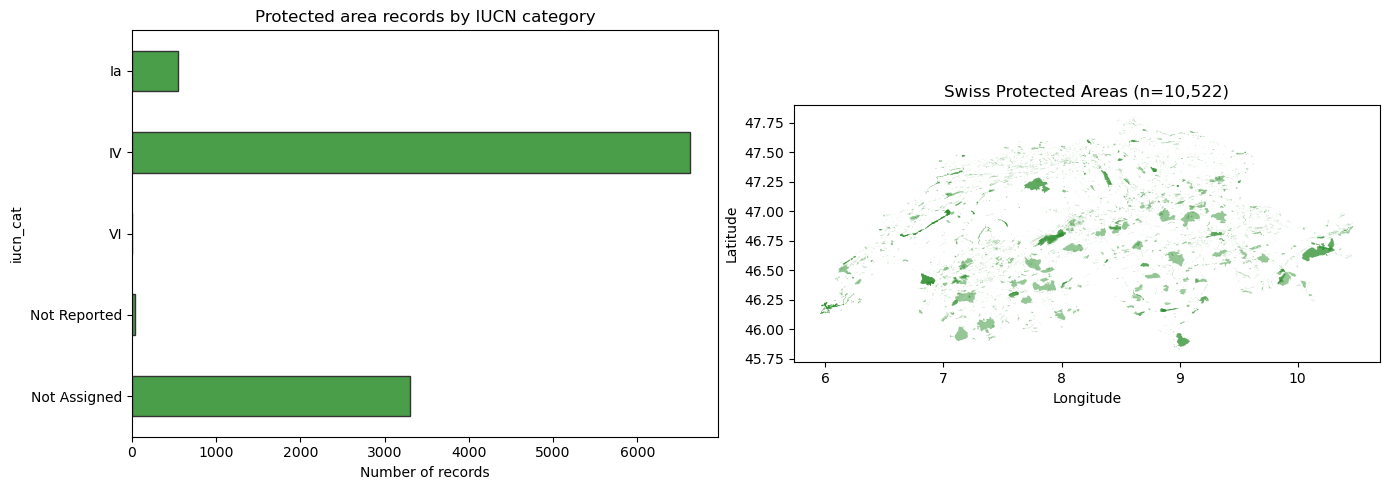

In [16]:
# Visualise IUCN category distribution
iucn_order = ['Ia', 'Ib', 'II', 'III', 'IV', 'V', 'VI', 'Not Reported', 'Not Applicable']
cat_counts = pa_clean['iucn_cat'].value_counts()
# Reorder
cat_counts = cat_counts.reindex([c for c in iucn_order if c in cat_counts.index])
cat_counts = pd.concat([cat_counts, pa_clean['iucn_cat'].value_counts().drop(cat_counts.index, errors='ignore')])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: count by category
cat_counts.plot.barh(ax=axes[0], color='#4a9e4a', edgecolor='#333')
axes[0].set_xlabel('Number of records')
axes[0].set_title('Protected area records by IUCN category')
axes[0].invert_yaxis()

# Map overview
pa_clean.plot(ax=axes[1], color='#2d8e2d', alpha=0.5, edgecolor='none')
axes[1].set_title(f'Swiss Protected Areas (n={len(pa_clean):,})')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 6. Save cleaned GeoJSON

Overwrites the previous `protected_areas_ch.geojson` with the complete dataset.
This is the file consumed by notebook 31 (gap analysis).

In [17]:
# Save
pa_clean.to_file(OUTPUT_GEOJSON, driver='GeoJSON')
file_size_mb = os.path.getsize(OUTPUT_GEOJSON) / 1e6
print(f'Saved: {OUTPUT_GEOJSON} ({file_size_mb:.1f} MB, {len(pa_clean):,} features)')

# Verify round-trip
pa_verify = gpd.read_file(OUTPUT_GEOJSON)
assert len(pa_verify) == len(pa_clean), 'Round-trip verification failed!'
print(f'Verified: {len(pa_verify):,} features read back successfully.')

Saved: protected_areas_ch.geojson (172.8 MB, 10,522 features)
Verified: 10,522 features read back successfully.


### 7. Cleanup

In [18]:
# Remove temp files
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)
print('Temp files cleaned up.')

print(f'\n=== Done ===')
print(f'Protected areas file ready: {OUTPUT_GEOJSON}')

Temp files cleaned up.

=== Done ===
Protected areas file ready: protected_areas_ch.geojson
